Saving Lotof.csv to Lotof.csv
Dados carregados: 3640 concursos
Números primos: [2, 3, 5, 7, 11, 13, 17, 19, 23]
Números Fibonacci: [1, 1, 2, 3, 5, 8, 13, 21]
Moldura: [1, 2, 3, 4, 5, 6, 10, 11, 15, 16, 20, 21, 22, 23, 24, 25]
Centro: [7, 8, 9, 12, 13, 14, 17, 18, 19]
Matriz binária criada

===== ESTATÍSTICAS BÁSICAS =====
Total de aparições: 54600
Frequência média: 2184.00
Desvio padrão das frequências: 45.96

Calculando features básicas...
Calculando features de posição...
Calculando análise de saltos...
Calculando padrões consecutivos...
Calculando números irmãos...
Calculando análises temporais...
Calculando repetições entre concursos...
Aplicando Princípio de Pareto...
Calculando números quentes e frios...
Calculando distribuições estatísticas...
Calculando correlações...
Gerando visualizações...


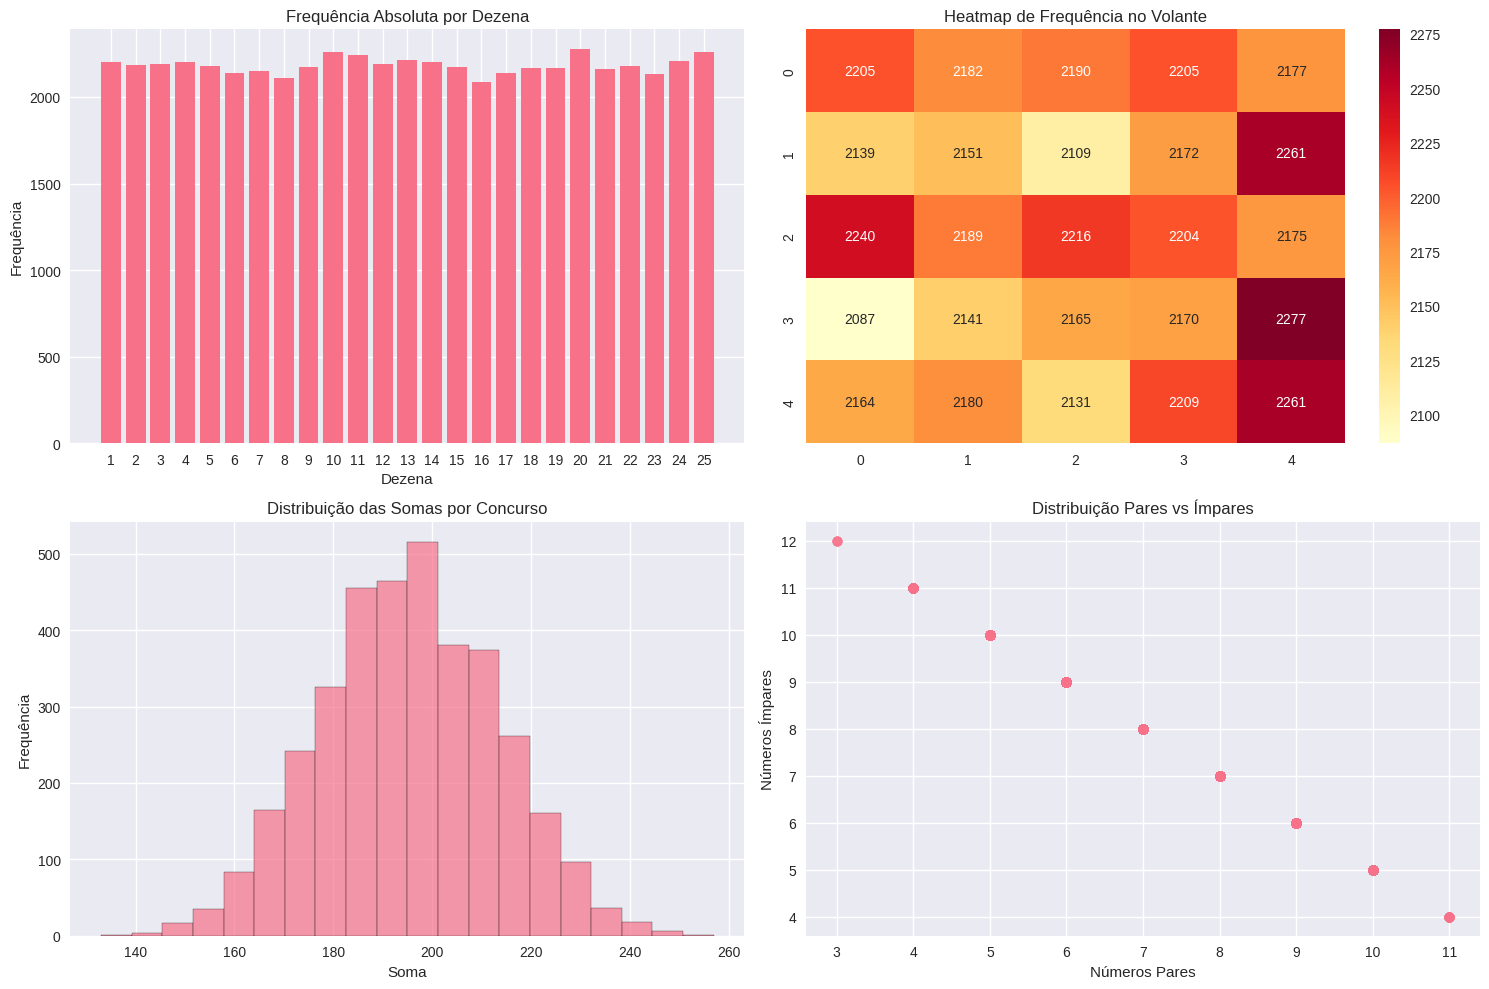

Preparando dados para modelagem...
Dados preparados: 3639 amostras, 600 features
Treino: 3629 amostras
Teste: 10 amostras

===== TREINAMENTO DOS MODELOS =====
Treinando Random Forest...
Treinando Regressão Logística...

===== AVALIAÇÃO - RANDOM FOREST =====
Acurácia média: 0.5920 (59.20%)
Média de acertos por jogo: 14.80/25
Média de números sorteados previstos corretamente: 14.50/15
Precision média: 0.5993
Recall médio: 0.9667
F1-Score médio: 0.7399

Detalhamento por concurso:
  Concurso 3631: 14/15 sorteados corretos (93.33%) | Total: 14/25 (56.00%) | Predições: 24
  Concurso 3632: 13/15 sorteados corretos (86.67%) | Total: 14/25 (56.00%) | Predições: 22
  Concurso 3633: 14/15 sorteados corretos (93.33%) | Total: 14/25 (56.00%) | Predições: 24
  Concurso 3634: 15/15 sorteados corretos (100.00%) | Total: 15/25 (60.00%) | Predições: 25
  Concurso 3635: 15/15 sorteados corretos (100.00%) | Total: 15/25 (60.00%) | Predições: 25
  Concurso 3636: 15/15 sorteados corretos (100.00%) | Total: 

In [ ]:
# -*- coding: utf-8 -*-
"""
Modelo Lotofácil Aprimorado - Random Forest e Regressão Linear
Versão com features expandidas e análises mais detalhadas
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from scipy import stats
from google import colab as cl
from itertools import combinations
import warnings
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')


# Carregar os dados
# Em ambiente Google Colab:
# from google.colab import files
# uploaded = files.upload()  # Faz upload do arquivo CSV
# df = pd.read_csv('Lotofa.csv', sep=';')

#importando arq
file_upload = cl.files.upload()


# Configuração de plotagem
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette("husl")

# Carregar os dados
file_path = "Lotof.csv"
df = pd.read_csv(file_path, sep=';')

print(f"Dados carregados: {len(df)} concursos")

# Pré-processamento dos dados
balls = [f'Bola{i}' for i in range(1, 16)]
df_balls = df[balls].copy()

# ===== FUNÇÕES AUXILIARES =====

def is_prime(n):
    """Verifica se um número é primo"""
    if n <= 1:
        return False
    if n <= 3:
        return True
    if n % 2 == 0 or n % 3 == 0:
        return False
    i = 5
    while i * i <= n:
        if n % i == 0 or n % (i + 2) == 0:
            return False
        i += 6
    return True

def is_fibonacci(n):
    """Verifica se um número é fibonacci"""
    def is_perfect_square(x):
        s = int(np.sqrt(x))
        return s*s == x
    return is_perfect_square(5*n*n + 4) or is_perfect_square(5*n*n - 4)

def get_position(num):
    """Retorna linha e coluna do número no volante 5x5"""
    linha = (num - 1) // 5 + 1
    coluna = (num - 1) % 5 + 1
    return linha, coluna

def is_moldura(num):
    """Verifica se o número está na moldura (bordas) do volante"""
    linha, coluna = get_position(num)
    return linha == 1 or linha == 5 or coluna == 1 or coluna == 5

def is_centro(num):
    """Verifica se o número está no centro do volante"""
    return not is_moldura(num)

def get_diagonal(num):
    """Identifica se o número está nas diagonais"""
    linha, coluna = get_position(num)
    diagonal_principal = (linha == coluna)
    diagonal_secundaria = (linha + coluna == 6)
    return diagonal_principal, diagonal_secundaria

def calculate_gaps(series):
    """Calcula gaps entre ocorrências"""
    indices = series[series == 1].index
    if len(indices) <= 1:
        return []
    return np.diff(indices).tolist()

def bernoulli_probability(successes, trials):
    """Calcula probabilidade usando distribuição de Bernoulli"""
    if trials == 0:
        return 0
    return successes / trials

# ===== CONSTANTES =====
primes = [n for n in range(1, 26) if is_prime(n)]
fibonacci_nums = [1, 1, 2, 3, 5, 8, 13, 21]  # Fibonacci até 25
moldura_nums = [n for n in range(1, 26) if is_moldura(n)]
centro_nums = [n for n in range(1, 26) if is_centro(n)]

print(f"Números primos: {primes}")
print(f"Números Fibonacci: {fibonacci_nums}")
print(f"Moldura: {moldura_nums}")
print(f"Centro: {centro_nums}")

# ===== CRIAR MATRIZ BINÁRIA =====
binary_matrix = pd.DataFrame(index=df.index, columns=range(1, 26), dtype=int)
for num in range(1, 26):
    binary_matrix[num] = df_balls.isin([num]).any(axis=1).astype(int)

print("Matriz binária criada")

# ===== ANÁLISES ESTATÍSTICAS BÁSICAS =====

# Frequências
freq_abs = binary_matrix.sum()
freq_rel = freq_abs / len(df)
total_aparicoes = freq_abs.sum()

print("\n===== ESTATÍSTICAS BÁSICAS =====")
print(f"Total de aparições: {total_aparicoes}")
print(f"Frequência média: {freq_abs.mean():.2f}")
print(f"Desvio padrão das frequências: {freq_abs.std():.2f}")

# ===== FEATURES EXPANDIDAS =====

# 1. FEATURES BÁSICAS
print("\nCalculando features básicas...")

# Estatísticas por jogo
df['soma'] = df_balls.sum(axis=1)
df['media'] = df_balls.mean(axis=1)
df['mediana'] = df_balls.apply(lambda x: np.median(x), axis=1)
df['std'] = df_balls.apply(lambda x: np.std(x), axis=1)
df['amplitude'] = df_balls.max(axis=1) - df_balls.min(axis=1)
df['q1'] = df_balls.apply(lambda x: np.percentile(x, 25), axis=1)
df['q3'] = df_balls.apply(lambda x: np.percentile(x, 75), axis=1)

# Distribuições
df['pares'] = df_balls.apply(lambda x: sum(n % 2 == 0 for n in x), axis=1)
df['impares'] = 15 - df['pares']
df['baixos'] = df_balls.apply(lambda x: sum(n <= 13 for n in x), axis=1)
df['altos'] = 15 - df['baixos']
df['primos'] = df_balls.apply(lambda x: sum(n in primes for n in x), axis=1)
df['fibonacci'] = df_balls.apply(lambda x: sum(n in fibonacci_nums for n in x), axis=1)
df['mult_2'] = df_balls.apply(lambda x: sum(n % 2 == 0 for n in x), axis=1)
df['mult_3'] = df_balls.apply(lambda x: sum(n % 3 == 0 for n in x), axis=1)
df['mult_5'] = df_balls.apply(lambda x: sum(n % 5 == 0 for n in x), axis=1)
df['mult_7'] = df_balls.apply(lambda x: sum(n % 7 == 0 for n in x), axis=1)

# Moldura e centro
df['moldura'] = df_balls.apply(lambda x: sum(n in moldura_nums for n in x), axis=1)
df['centro'] = df_balls.apply(lambda x: sum(n in centro_nums for n in x), axis=1)

# 2. ANÁLISE DE POSIÇÕES NO VOLANTE
print("Calculando features de posição...")

# Por linha (1-5)
for linha in range(1, 6):
    nums_linha = [n for n in range(1, 26) if get_position(n)[0] == linha]
    df[f'linha_{linha}'] = df_balls.apply(lambda x: sum(n in nums_linha for n in x), axis=1)

# Por coluna (1-5)
for coluna in range(1, 6):
    nums_coluna = [n for n in range(1, 26) if get_position(n)[1] == coluna]
    df[f'coluna_{coluna}'] = df_balls.apply(lambda x: sum(n in nums_coluna for n in x), axis=1)

# Diagonais
diag_principal = [1, 7, 13, 19, 25]
diag_secundaria = [5, 9, 13, 17, 21]
df['diag_principal'] = df_balls.apply(lambda x: sum(n in diag_principal for n in x), axis=1)
df['diag_secundaria'] = df_balls.apply(lambda x: sum(n in diag_secundaria for n in x), axis=1)

# 3. ANÁLISE DE SALTOS
print("Calculando análise de saltos...")

def calculate_jumps(row):
    """Calcula estatísticas de saltos entre números consecutivos"""
    sorted_nums = sorted(row)
    jumps = [sorted_nums[i+1] - sorted_nums[i] for i in range(len(sorted_nums)-1)]
    return {
        'salto_min': min(jumps),
        'salto_max': max(jumps),
        'salto_medio': np.mean(jumps),
        'saltos_1': sum(1 for j in jumps if j == 1),  # consecutivos
        'saltos_grandes': sum(1 for j in jumps if j > 5)  # saltos grandes
    }

saltos_info = df_balls.apply(lambda x: calculate_jumps(x), axis=1)
for key in ['salto_min', 'salto_max', 'salto_medio', 'saltos_1', 'saltos_grandes']:
    df[key] = [info[key] for info in saltos_info]

# 4. PADRÕES CONSECUTIVOS
print("Calculando padrões consecutivos...")

def count_consecutive_patterns(df_balls, pattern_size):
    """Conta padrões consecutivos"""
    patterns = Counter()
    for _, row in df_balls.iterrows():
        sorted_values = sorted(row)
        for i in range(len(sorted_values) - pattern_size + 1):
            consecutive = True
            for j in range(pattern_size - 1):
                if sorted_values[i + j + 1] - sorted_values[i + j] != 1:
                    consecutive = False
                    break
            if consecutive:
                pattern = tuple(sorted_values[i:i + pattern_size])
                patterns[pattern] += 1
    return patterns

# Padrões mais frequentes
duplas_consecutivas = count_consecutive_patterns(df_balls, 2)
trincas_consecutivas = count_consecutive_patterns(df_balls, 3)
quadras_consecutivas = count_consecutive_patterns(df_balls, 4)

# Contar ocorrências por jogo
df['duplas_consec'] = df_balls.apply(lambda x: sum(1 for i in range(len(sorted(x))-1)
                                                   if sorted(x)[i+1] - sorted(x)[i] == 1), axis=1)
df['trincas_consec'] = df_balls.apply(lambda x: sum(1 for i in range(len(sorted(x))-2)
                                                    if all(sorted(x)[i+j+1] - sorted(x)[i+j] == 1 for j in range(2))), axis=1)

# 5. NÚMEROS IRMÃOS (diferença de 1 ou múltiplos)
print("Calculando números irmãos...")

def count_irmaos(row):
    """Conta pares de números 'irmãos' (consecutivos ou com relação especial)"""
    sorted_nums = sorted(row)
    irmaos = 0
    for i in range(len(sorted_nums)):
        for j in range(i+1, len(sorted_nums)):
            diff = abs(sorted_nums[j] - sorted_nums[i])
            if diff == 1 or diff == 5 or diff == 10:  # diferentes tipos de "irmandade"
                irmaos += 1
    return irmaos

df['irmaos'] = df_balls.apply(count_irmaos, axis=1)

# 6. ANÁLISE TEMPORAL E CICLOS
print("Calculando análises temporais...")

# Médias móveis para cada número
moving_averages = {}
for window in [5, 10, 15, 20]:
    moving_averages[window] = binary_matrix.rolling(window=window, min_periods=1).mean()

# Gaps desde última ocorrência
gaps = {}
for num in range(1, 26):
    gaps[num] = []
    last_occurrence = -1
    for i, occurred in enumerate(binary_matrix[num]):
        if occurred:
            if last_occurrence >= 0:
                gaps[num].append(i - last_occurrence)
            last_occurrence = i

# Ciclos médios
ciclos_medios = {}
for num in range(1, 26):
    if gaps[num]:
        ciclos_medios[num] = np.mean(gaps[num])
    else:
        ciclos_medios[num] = len(df)  # Nunca saiu

# 7. ANÁLISE DE REPETIÇÕES ENTRE CONCURSOS
print("Calculando repetições entre concursos...")

repeticoes = []
for i in range(1, len(df_balls)):
    conjunto_atual = set(df_balls.iloc[i])
    conjunto_anterior = set(df_balls.iloc[i-1])
    repeticoes.append(len(conjunto_atual & conjunto_anterior))

df['repeticoes'] = [0] + repeticoes

# 8. PRINCÍPIO DE PARETO
print("Aplicando Princípio de Pareto...")

# 20% dos números que mais aparecem
freq_ordenada = freq_abs.sort_values(ascending=False)
pareto_20_percent = int(0.2 * len(freq_ordenada))
numeros_pareto = freq_ordenada.head(pareto_20_percent).index.tolist()
df['pareto_nums'] = df_balls.apply(lambda x: sum(n in numeros_pareto for n in x), axis=1)

# 9. NÚMEROS QUENTES E FRIOS (dinâmico)
print("Calculando números quentes e frios...")

def get_hot_cold_numbers(window=30):
    """Identifica números quentes e frios baseado em janela móvel"""
    if len(df_balls) < window:
        window = len(df_balls)

    recent_freq = binary_matrix.tail(window).mean()
    overall_freq = binary_matrix.mean()

    hot_threshold = overall_freq.mean() + overall_freq.std()
    cold_threshold = overall_freq.mean() - overall_freq.std()

    hot_numbers = recent_freq[recent_freq > hot_threshold].index.tolist()
    cold_numbers = recent_freq[recent_freq < cold_threshold].index.tolist()

    return hot_numbers, cold_numbers

# Aplicar para diferentes janelas
for window in [10, 20, 30]:
    hot, cold = get_hot_cold_numbers(window)
    df[f'hot_{window}'] = df_balls.apply(lambda x: sum(n in hot for n in x), axis=1)
    df[f'cold_{window}'] = df_balls.apply(lambda x: sum(n in cold for n in x), axis=1)

# 10. ANÁLISE DE DISTRIBUIÇÃO ESTATÍSTICA
print("Calculando distribuições estatísticas...")

# Teste de normalidade para cada jogo
df['normalidade'] = df_balls.apply(lambda x: stats.normaltest(x)[1], axis=1)  # p-valor

# Assimetria e curtose
df['assimetria'] = df_balls.apply(lambda x: stats.skew(x), axis=1)
df['curtose'] = df_balls.apply(lambda x: stats.kurtosis(x), axis=1)

# ===== CORRELAÇÕES E COMBINAÇÕES =====
print("Calculando correlações...")

correlation_matrix = binary_matrix.corr()

# Pares mais frequentes
pares_frequentes = Counter()
for _, row in df_balls.iterrows():
    for pair in combinations(row, 2):
        pares_frequentes[tuple(sorted(pair))] += 1

# Top 10 pares mais frequentes
top_pares = dict(pares_frequentes.most_common(10))

# ===== VISUALIZAÇÕES =====
print("Gerando visualizações...")

# 1. Heatmap de frequências
plt.figure(figsize=(15, 10))

# Subplot 1: Frequência por número
plt.subplot(2, 2, 1)
plt.bar(range(1, 26), freq_abs.values)
plt.title('Frequência Absoluta por Dezena')
plt.xlabel('Dezena')
plt.ylabel('Frequência')
plt.xticks(range(1, 26))

# Subplot 2: Heatmap do volante
plt.subplot(2, 2, 2)
volante_freq = np.zeros((5, 5))
for num in range(1, 26):
    linha, coluna = get_position(num)
    volante_freq[linha-1, coluna-1] = freq_abs[num]

sns.heatmap(volante_freq, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Heatmap de Frequência no Volante')

# Subplot 3: Distribuição de somas
plt.subplot(2, 2, 3)
plt.hist(df['soma'], bins=20, alpha=0.7, edgecolor='black')
plt.title('Distribuição das Somas por Concurso')
plt.xlabel('Soma')
plt.ylabel('Frequência')

# Subplot 4: Pares vs Ímpares
plt.subplot(2, 2, 4)
plt.scatter(df['pares'], df['impares'], alpha=0.6)
plt.title('Distribuição Pares vs Ímpares')
plt.xlabel('Números Pares')
plt.ylabel('Números Ímpares')

plt.tight_layout()
plt.show()

# ===== PREPARAÇÃO DOS DADOS PARA MODELAGEM =====
print("Preparando dados para modelagem...")

# Selecionar features para o modelo
feature_columns = [col for col in df.columns if col not in ['Concurso'] + balls]
X_features = df[feature_columns].fillna(0)

# Preparar dados com histórico para cada número
X = []
y = []

for i in range(1, len(df)):
    current_features = []

    for num in range(1, 26):
        # Features básicas do número
        freq_feature = binary_matrix.iloc[:i, num-1].mean() if i > 0 else 0

        # Gap desde última ocorrência
        if i > 0 and binary_matrix.iloc[:i, num-1].any():
            last_idx = binary_matrix.iloc[:i, num-1][::-1].idxmax()
            gap_feature = i - last_idx
        else:
            gap_feature = i

        # Médias móveis
        last_5 = binary_matrix.iloc[max(0, i-5):i, num-1].mean() if i > 0 else 0
        last_10 = binary_matrix.iloc[max(0, i-10):i, num-1].mean() if i > 0 else 0
        last_15 = binary_matrix.iloc[max(0, i-15):i, num-1].mean() if i > 0 else 0
        last_20 = binary_matrix.iloc[max(0, i-20):i, num-1].mean() if i > 0 else 0

        # Características estáticas do número
        is_par = 1 if num % 2 == 0 else 0
        is_prime_feature = 1 if num in primes else 0
        is_fib = 1 if num in fibonacci_nums else 0
        is_moldura_feature = 1 if num in moldura_nums else 0
        linha, coluna = get_position(num)
        diag_principal_feature = 1 if num in diag_principal else 0
        diag_secundaria_feature = 1 if num in diag_secundaria else 0

        # Múltiplos
        mult_2 = 1 if num % 2 == 0 else 0
        mult_3 = 1 if num % 3 == 0 else 0
        mult_5 = 1 if num % 5 == 0 else 0
        mult_7 = 1 if num % 7 == 0 else 0

        # Correlação média com outros números
        avg_corr = correlation_matrix.iloc[num-1, :].mean()

        # Ciclo médio
        ciclo_medio = ciclos_medios.get(num, len(df))

        # Probabilidade de Bernoulli
        bernoulli_prob = bernoulli_probability(
            binary_matrix.iloc[:i, num-1].sum() if i > 0 else 0, i
        )

        # Features do concurso anterior (se existir)
        if i > 0:
            pares_anterior = X_features.iloc[i-1]['pares']
            soma_anterior = X_features.iloc[i-1]['soma']
            std_anterior = X_features.iloc[i-1]['std']
        else:
            pares_anterior = soma_anterior = std_anterior = 0

        # Adicionar todas as features
        current_features.extend([
            freq_feature, gap_feature, last_5, last_10, last_15, last_20,
            is_par, is_prime_feature, is_fib, is_moldura_feature,
            linha, coluna, diag_principal_feature, diag_secundaria_feature,
            mult_2, mult_3, mult_5, mult_7, avg_corr, ciclo_medio,
            bernoulli_prob, pares_anterior, soma_anterior, std_anterior
        ])

    X.append(current_features)
    y.append(binary_matrix.iloc[i, :].values)

X = np.array(X)
y = np.array(y)

print(f"Dados preparados: {X.shape[0]} amostras, {X.shape[1]} features")

# ===== DIVISÃO EM TREINO E TESTE (10 ÚLTIMOS CONCURSOS) =====
test_size = 10
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===== MODELAGEM =====
print("\n===== TREINAMENTO DOS MODELOS =====")

# Random Forest
print("Treinando Random Forest...")
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf = MultiOutputClassifier(rf_base)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

# Regressão Logística
print("Treinando Regressão Logística...")
lr_base = LogisticRegression(
    max_iter=3000,
    C=0.1,
    solver='liblinear',
    random_state=42
)
lr = MultiOutputClassifier(lr_base)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# ===== AVALIAÇÃO DOS MODELOS =====
def evaluate_model_detailed(y_true, y_pred, model_name):
    """Avaliação detalhada do modelo"""
    print(f"\n===== AVALIAÇÃO - {model_name.upper()} =====")

    correct_per_game = np.sum(y_true == y_pred, axis=1)
    true_positives = np.sum((y_true == 1) & (y_pred == 1), axis=1)
    predicted_positives = np.sum(y_pred == 1, axis=1)
    actual_positives = np.sum(y_true == 1, axis=1)

    # Métricas gerais
    accuracy = np.mean(correct_per_game) / 25
    avg_true_positives = np.mean(true_positives)
    avg_precision = np.mean([tp/pp if pp > 0 else 0 for tp, pp in zip(true_positives, predicted_positives)])
    avg_recall = np.mean(true_positives) / 15
    avg_f1 = 2 * avg_precision * avg_recall / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0

    print(f"Acurácia média: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Média de acertos por jogo: {np.mean(correct_per_game):.2f}/25")
    print(f"Média de números sorteados previstos corretamente: {avg_true_positives:.2f}/15")
    print(f"Precision média: {avg_precision:.4f}")
    print(f"Recall médio: {avg_recall:.4f}")
    print(f"F1-Score médio: {avg_f1:.4f}")

    # Análise por concurso
    print(f"\nDetalhamento por concurso:")
    for i in range(len(y_true)):
        concurso_num = len(df) - test_size + i + 1
        acertos_totais = correct_per_game[i]
        acertos_sorteados = true_positives[i]
        previsoes_positivas = predicted_positives[i]

        print(f"  Concurso {concurso_num}: {acertos_sorteados}/15 sorteados corretos "
              f"({acertos_sorteados/15:.2%}) | Total: {acertos_totais}/25 "
              f"({acertos_totais/25:.2%}) | Predições: {previsoes_positivas}")

    # Estatísticas de distribuição de acertos
    print(f"\nEstatísticas dos acertos:")
    print(f"  Mínimo de acertos sorteados: {np.min(true_positives)}")
    print(f"  Máximo de acertos sorteados: {np.max(true_positives)}")
    print(f"  Mediana de acertos sorteados: {np.median(true_positives)}")
    print(f"  Desvio padrão: {np.std(true_positives):.2f}")

    return {
        'accuracy': accuracy,
        'precision': avg_precision,
        'recall': avg_recall,
        'f1': avg_f1,
        'avg_true_positives': avg_true_positives,
        'true_positives_detail': true_positives
    }

# Avaliar modelos
rf_metrics = evaluate_model_detailed(y_test, rf_pred, "Random Forest")
lr_metrics = evaluate_model_detailed(y_test, lr_pred, "Regressão Logística")

# Comparação dos modelos
print(f"\n===== COMPARAÇÃO DOS MODELOS =====")
print(f"Random Forest - F1: {rf_metrics['f1']:.4f} | Acertos médios: {rf_metrics['avg_true_positives']:.2f}")
print(f"Regressão Logística - F1: {lr_metrics['f1']:.4f} | Acertos médios: {lr_metrics['avg_true_positives']:.2f}")

# Selecionar melhor modelo
if rf_metrics['f1'] >= lr_metrics['f1']:
    best_model = rf
    best_model_name = "Random Forest"
    best_metrics = rf_metrics
else:
    best_model = lr
    best_model_name = "Regressão Logística"
    best_metrics = lr_metrics

print(f"\nMelhor modelo: {best_model_name} (F1-Score: {best_metrics['f1']:.4f})")

# ===== ANÁLISE DE IMPORTÂNCIA (RANDOM FOREST) =====
if best_model_name == "Random Forest":
    print(f"\n===== IMPORTÂNCIA DAS FEATURES - RANDOM FOREST =====")

    # Nomes das features
    feature_names = []
    for num in range(1, 26):
        base_names = [
            'freq', 'gap', 'ma5', 'ma10', 'ma15', 'ma20', 'par', 'primo', 'fib',
            'moldura', 'linha', 'coluna', 'diag_prin', 'diag_sec', 'mult2', 'mult3',
            'mult5', 'mult7', 'corr', 'ciclo', 'bernoulli', 'pares_ant', 'soma_ant', 'std_ant'
        ]
        feature_names.extend([f"{name}_{num:02d}" for name in base_names])

    # Calcular importância média
    importances = np.mean([estimator.feature_importances_ for estimator in best_model.estimators_], axis=0)

    # Agrupar por tipo de feature
    importance_by_type = defaultdict(list)
    for i, feature_name in enumerate(feature_names):
        if i < len(importances):
            feature_type = feature_name.split('_')[0]
            importance_by_type[feature_type].append(importances[i])

    # Calcular importância média por tipo
    mean_importance_by_type = {
        feature_type: np.mean(values)
        for feature_type, values in importance_by_type.items()
    }

    # Ordenar e exibir
    sorted_importance = sorted(mean_importance_by_type.items(), key=lambda x: x[1], reverse=True)

    print("Importância média por tipo de feature:")
    for feature_type, importance in sorted_importance:
        print(f"  {feature_type:<12}: {importance:.6f}")

    # Top 20 features mais importantes individualmente
    feature_importance_pairs = list(zip(feature_names[:len(importances)], importances))
    top_features = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)[:20]

    print(f"\nTop 20 features mais importantes:")
    for i, (feature, importance) in enumerate(top_features, 1):
        print(f"  {i:2d}. {feature:<20}: {importance:.6f}")

# ===== PREVISÃO PARA O PRÓXIMO CONCURSO =====
print(f"\n===== PREVISÃO PARA O PRÓXIMO CONCURSO =====")

def predict_next_game(model, scaler, top_k=18):
    """Prediz os top K números para o próximo concurso"""

    # Preparar features para o próximo concurso
    next_features = []
    current_idx = len(df)

    for num in range(1, 26):
        # Features básicas do número
        freq_feature = binary_matrix[num].mean()

        # Gap desde última ocorrência
        if binary_matrix[num].any():
            last_idx = binary_matrix[num][::-1].idxmax()
            gap_feature = current_idx - last_idx
        else:
            gap_feature = current_idx

        # Médias móveis
        last_5 = binary_matrix[num].tail(5).mean()
        last_10 = binary_matrix[num].tail(10).mean()
        last_15 = binary_matrix[num].tail(15).mean()
        last_20 = binary_matrix[num].tail(20).mean()

        # Características estáticas
        is_par = 1 if num % 2 == 0 else 0
        is_prime_feature = 1 if num in primes else 0
        is_fib = 1 if num in fibonacci_nums else 0
        is_moldura_feature = 1 if num in moldura_nums else 0
        linha, coluna = get_position(num)
        diag_principal_feature = 1 if num in diag_principal else 0
        diag_secundaria_feature = 1 if num in diag_secundaria else 0

        # Múltiplos
        mult_2 = 1 if num % 2 == 0 else 0
        mult_3 = 1 if num % 3 == 0 else 0
        mult_5 = 1 if num % 5 == 0 else 0
        mult_7 = 1 if num % 7 == 0 else 0

        # Correlação e ciclo
        avg_corr = correlation_matrix.iloc[num-1, :].mean()
        ciclo_medio = ciclos_medios.get(num, len(df))

        # Probabilidade de Bernoulli
        bernoulli_prob = bernoulli_probability(binary_matrix[num].sum(), len(binary_matrix))

        # Features do último concurso
        pares_anterior = X_features.iloc[-1]['pares']
        soma_anterior = X_features.iloc[-1]['soma']
        std_anterior = X_features.iloc[-1]['std']

        next_features.extend([
            freq_feature, gap_feature, last_5, last_10, last_15, last_20,
            is_par, is_prime_feature, is_fib, is_moldura_feature,
            linha, coluna, diag_principal_feature, diag_secundaria_feature,
            mult_2, mult_3, mult_5, mult_7, avg_corr, ciclo_medio,
            bernoulli_prob, pares_anterior, soma_anterior, std_anterior
        ])

    next_features = np.array([next_features])
    next_features_scaled = scaler.transform(next_features)

    # Fazer previsão
    if hasattr(model, 'predict_proba'):
        # Tentar obter probabilidades
        try:
            probabilities = []
            for i, estimator in enumerate(model.estimators_):
                if hasattr(estimator, 'predict_proba'):
                    prob = estimator.predict_proba(next_features_scaled)[0]
                    # Pegar probabilidade da classe positiva (índice 1)
                    if len(prob) > 1:
                        probabilities.append(prob[1])
                    else:
                        probabilities.append(estimator.predict(next_features_scaled)[0])
                else:
                    probabilities.append(estimator.predict(next_features_scaled)[0])
        except:
            # Fallback para previsão simples
            prediction = model.predict(next_features_scaled)[0]
            probabilities = prediction.astype(float)
    else:
        prediction = model.predict(next_features_scaled)[0]
        probabilities = prediction.astype(float)

    # Selecionar top K números
    if len(probabilities) == 25:
        top_indices = np.argsort(probabilities)[-top_k:]
        top_numbers = [idx + 1 for idx in top_indices]
        top_probs = [probabilities[idx] for idx in top_indices]
    else:
        # Fallback
        top_numbers = list(range(1, min(top_k + 1, 26)))
        top_probs = [0.5] * len(top_numbers)

    return sorted(top_numbers), top_probs

# Fazer previsão com o melhor modelo
predicted_numbers, predicted_probs = predict_next_game(best_model, scaler, 18)

print(f"Modelo utilizado: {best_model_name}")
print(f"As 18 dezenas previstas para o próximo concurso ({len(df) + 1}):")
print(f"Números: {predicted_numbers}")

# ===== ANÁLISE DA PREVISÃO =====
print(f"\n===== ANÁLISE DA PREVISÃO =====")

# Distribuições da previsão
pred_pares = sum(n % 2 == 0 for n in predicted_numbers)
pred_impares = len(predicted_numbers) - pred_pares
pred_baixos = sum(n <= 13 for n in predicted_numbers)
pred_altos = len(predicted_numbers) - pred_baixos
pred_primos = sum(n in primes for n in predicted_numbers)
pred_fibonacci = sum(n in fibonacci_nums for n in predicted_numbers)
pred_moldura = sum(n in moldura_nums for n in predicted_numbers)
pred_centro = sum(n in centro_nums for n in predicted_numbers)

print(f"Distribuição da previsão:")
print(f"  Pares: {pred_pares} | Ímpares: {pred_impares}")
print(f"  Baixos (1-13): {pred_baixos} | Altos (14-25): {pred_altos}")
print(f"  Primos: {pred_primos}")
print(f"  Fibonacci: {pred_fibonacci}")
print(f"  Moldura: {pred_moldura} | Centro: {pred_centro}")

# Múltiplos
pred_mult_3 = sum(n % 3 == 0 for n in predicted_numbers)
pred_mult_5 = sum(n % 5 == 0 for n in predicted_numbers)
pred_mult_7 = sum(n % 7 == 0 for n in predicted_numbers)

print(f"  Múltiplos de 3: {pred_mult_3}")
print(f"  Múltiplos de 5: {pred_mult_5}")
print(f"  Múltiplos de 7: {pred_mult_7}")

# Estatísticas da previsão
pred_soma = sum(predicted_numbers)
pred_media = np.mean(predicted_numbers)
pred_std = np.std(predicted_numbers)

print(f"\nEstatísticas:")
print(f"  Soma: {pred_soma}")
print(f"  Média: {pred_media:.2f}")
print(f"  Desvio Padrão: {pred_std:.2f}")

# Análise de saltos
pred_sorted = sorted(predicted_numbers)
pred_saltos = [pred_sorted[i+1] - pred_sorted[i] for i in range(len(pred_sorted)-1)]
pred_salto_medio = np.mean(pred_saltos)
pred_consecutivos = sum(1 for s in pred_saltos if s == 1)

print(f"  Salto médio: {pred_salto_medio:.2f}")
print(f"  Números consecutivos: {pred_consecutivos}")

# Comparação com médias históricas
print(f"\n===== COMPARAÇÃO COM HISTÓRICO =====")
hist_means = {
    'pares': df['pares'].mean(),
    'impares': df['impares'].mean(),
    'baixos': df['baixos'].mean(),
    'altos': df['altos'].mean(),
    'primos': df['primos'].mean(),
    'fibonacci': df['fibonacci'].mean(),
    'moldura': df['moldura'].mean(),
    'centro': df['centro'].mean(),
    'mult_3': df['mult_3'].mean(),
    'mult_5': df['mult_5'].mean(),
    'soma': df['soma'].mean(),
    'std': df['std'].mean()
}

print("Comparação (Previsão vs Média Histórica):")
print(f"  Pares: {pred_pares} vs {hist_means['pares']:.1f}")
print(f"  Ímpares: {pred_impares} vs {hist_means['impares']:.1f}")
print(f"  Baixos: {pred_baixos} vs {hist_means['baixos']:.1f}")
print(f"  Altos: {pred_altos} vs {hist_means['altos']:.1f}")
print(f"  Primos: {pred_primos} vs {hist_means['primos']:.1f}")
print(f"  Fibonacci: {pred_fibonacci} vs {hist_means['fibonacci']:.1f}")
print(f"  Moldura: {pred_moldura} vs {hist_means['moldura']:.1f}")
print(f"  Centro: {pred_centro} vs {hist_means['centro']:.1f}")
print(f"  Múlt. 3: {pred_mult_3} vs {hist_means['mult_3']:.1f}")
print(f"  Múlt. 5: {pred_mult_5} vs {hist_means['mult_5']:.1f}")
print(f"  Soma: {pred_soma} vs {hist_means['soma']:.1f}")
print(f"  Desvio: {pred_std:.2f} vs {hist_means['std']:.2f}")

# ===== NÚMEROS MAIS E MENOS PROVÁVEIS =====
print(f"\n===== ANÁLISE DE PROBABILIDADE POR NÚMERO =====")

# Calcular gaps atuais
gaps_atuais = {}
for num in range(1, 26):
    if binary_matrix[num].any():
        last_idx = binary_matrix[num][::-1].idxmax()
        gaps_atuais[num] = len(binary_matrix) - last_idx
    else:
        gaps_atuais[num] = len(binary_matrix)

# Números mais atrasados (maiores gaps)
nums_atrasados = sorted(gaps_atuais.items(), key=lambda x: x[1], reverse=True)
print("Top 10 números mais atrasados:")
for i, (num, gap) in enumerate(nums_atrasados[:10], 1):
    freq = freq_abs[num]
    print(f"  {i:2d}. Número {num:2d}: {gap:3d} concursos sem sair (freq: {freq:3d})")

# Números mais frequentes
nums_frequentes = freq_abs.sort_values(ascending=False)
print(f"\nTop 10 números mais frequentes:")
for i, (num, freq) in enumerate(nums_frequentes.head(10).items(), 1):
    gap = gaps_atuais[num]
    print(f"  {i:2d}. Número {num:2d}: {freq:3d} aparições (gap atual: {gap:3d})")

# ===== DISTRIBUIÇÃO NO VOLANTE =====
print(f"\n===== DISTRIBUIÇÃO NO VOLANTE =====")

# Contar por linha e coluna
pred_por_linha = defaultdict(int)
pred_por_coluna = defaultdict(int)

for num in predicted_numbers:
    linha, coluna = get_position(num)
    pred_por_linha[linha] += 1
    pred_por_coluna[coluna] += 1

print("Distribuição por linha:")
for linha in range(1, 6):
    nums_linha = [n for n in predicted_numbers if get_position(n)[0] == linha]
    print(f"  Linha {linha}: {pred_por_linha[linha]} números {nums_linha}")

print("Distribuição por coluna:")
for coluna in range(1, 6):
    nums_coluna = [n for n in predicted_numbers if get_position(n)[1] == coluna]
    print(f"  Coluna {coluna}: {pred_por_coluna[coluna]} números {nums_coluna}")

# ===== RECOMENDAÇÕES FINAIS =====
print(f"\n===== RECOMENDAÇÕES E INSIGHTS =====")

# Verificar se a previsão está balanceada
desvios = []
if abs(pred_pares - hist_means['pares']) > 2:
    desvios.append(f"Pares muito {'alto' if pred_pares > hist_means['pares'] else 'baixo'}")

if abs(pred_baixos - hist_means['baixos']) > 2:
    desvios.append(f"Números baixos muito {'alto' if pred_baixos > hist_means['baixos'] else 'baixo'}")

if abs(pred_soma - hist_means['soma']) > 30:
    desvios.append(f"Soma muito {'alta' if pred_soma > hist_means['soma'] else 'baixa'}")

if desvios:
    print("⚠️  Atenção - Desvios significativos do padrão histórico:")
    for desvio in desvios:
        print(f"   • {desvio}")
else:
    print("✅ Previsão dentro dos padrões históricos esperados")

# Números de alta confiança (baseado em múltiplos critérios)
alta_confianca = []
for num in predicted_numbers:
    criterios = 0

    # Critério 1: Número atrasado (gap > média)
    if gaps_atuais[num] > np.mean(list(gaps_atuais.values())):
        criterios += 1

    # Critério 2: Frequência razoável
    if freq_abs[num] >= freq_abs.median():
        criterios += 1

    # Critério 3: Está na previsão
    criterios += 1

    if criterios >= 2:
        alta_confianca.append(num)

print(f"\nNúmeros de alta confiança: {sorted(alta_confianca)}")
print(f"Total de números de alta confiança: {len(alta_confianca)}")

# Sugestões de jogos
print(f"\n===== SUGESTÕES DE JOGOS =====")
print("Baseado na análise, sugerimos:")
print(f"1. Jogo principal (18 números): {predicted_numbers}")

# Versão mais conservadora (15 números com maior confiança)
if len(alta_confianca) >= 15:
    jogo_conservador = sorted(alta_confianca)[:15]
else:
    # Completar com números da previsão original
    remaining = [n for n in predicted_numbers if n not in alta_confianca]
    jogo_conservador = sorted(alta_confianca + remaining[:15-len(alta_confianca)])

print(f"2. Jogo conservador (15 números): {jogo_conservador}")

# Estatísticas finais dos modelos
print(f"\n===== ESTATÍSTICAS FINAIS =====")
print(f"Total de concursos analisados: {len(df)}")
print(f"Concursos usados para treino: {len(X_train)}")
print(f"Concursos usados para teste: {len(X_test)}")
print(f"Melhor modelo: {best_model_name}")
print(f"F1-Score do melhor modelo: {best_metrics['f1']:.4f}")
print(f"Acertos médios por concurso: {best_metrics['avg_true_positives']:.2f}/15")

print(f"\n🎯 PREVISÃO FINAL PARA O CONCURSO {len(df) + 1}:")
print(f"   {predicted_numbers}")
print(f"\n✨ BOA SORTE! ✨")